1D simple test: -u''(x) = f(x), u(0)=u(1)=0, exact solution u(x)=sin(pi x). 

In [29]:
import torch
import torch.nn as nn
torch.set_default_dtype(torch.float64)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 30),
            nn.Tanh(),
            nn.Linear(30, 30), 
            nn.Tanh(),
            nn.Linear(30, 1)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
def pde_residual(model, x):
    x = x.clone().detach().requires_grad_(True)

    u = model(x)
    du = torch.autograd.grad(
        u, x, torch.ones_like(u),
        create_graph=True
    )[0]
    d2u = torch.autograd.grad(
        du, x, torch.ones_like(du),
        create_graph=True
    )[0]

    f = (torch.pi**2) * torch.sin(torch.pi * x)
    return -d2u - f


def residual_vector(model, x_f):
    r_f = pde_residual(model, x_f)

    x0 = torch.tensor([[0.0]], requires_grad=True)
    x1 = torch.tensor([[1.0]], requires_grad=True)

    r_b0 = model(x0)
    r_b1 = model(x1)
    w_b = 1.0 
    return torch.cat([
        r_f.flatten(),
        w_b * r_b0.flatten(),
        w_b * r_b1.flatten()
    ])



def compute_jacobian(model, r):
    params = list(model.parameters())
    J = []

    for ri in r:
        grads = torch.autograd.grad(
            ri, params, retain_graph=True, allow_unused=True
        )
        grads = torch.cat([
            g.reshape(-1) if g is not None else torch.zeros_like(p).reshape(-1)
            for g, p in zip(grads, params)
        ])
        J.append(grads)

    return torch.stack(J)


def lm_step_adaptive(model, x, lam, lam_up, lam_down, max_trial):
    params = list(model.parameters())

    # flatten parameters
    theta0 = [p.data.clone() for p in params]

    # residual & loss (Tensor!)
    r0 = residual_vector(model, x)
    loss0 = 0.5 * torch.sum(r0**2)

    J = compute_jacobian(model, r0)
    A = J.T @ J + lam * torch.eye(J.shape[1])
    g = J.T @ r0.detach()

    delta = torch.linalg.solve(A, -g)

    for _ in range(max_trial):
        # trial update
        idx = 0
        for p, p0 in zip(params, theta0):
            numel = p.numel()
            p.data = p0 + delta[idx:idx+numel].view_as(p)
            idx += numel

        r1 = residual_vector(model, x)
        loss1 = 0.5 * torch.sum(r1**2)

        if loss1 < loss0:
            lam = max(lam / lam_down, 10**(-9))
            res = torch.sqrt(2 * loss1).item() 
            return lam, True, res
        else:
            # rollback
            for p, p0 in zip(params, theta0):
                p.data = p0
            lam = min(lam * lam_up, 10**8)

            res = torch.sqrt(2 * loss0).item()
            return lam, False, res

In [ ]:
model = Net()
#x_f = torch.rand(100, 1)
x_f = torch.linspace(0, 1, 100).view(-1, 1)

lam = 10000.0
lam_up = 3.0
lam_down = 1.3
max_trial = 100
res_hist = []
for it in range(2000):
    lam, ok, res = lm_step_adaptive(
        model, x_f, lam, lam_up, lam_down, max_trial
    )
    res_hist.append(res)
    status = "✓" if ok else "✗"
    print(f"iter {it:02d} | residual = {res:.3e} | λ = {lam:.1e} | {status}")



iter 00 | residual = 6.907e+01 | λ = 7.7e+07 | ✓
iter 01 | residual = 6.907e+01 | λ = 5.9e+07 | ✓
iter 02 | residual = 6.907e+01 | λ = 4.6e+07 | ✓
iter 03 | residual = 6.907e+01 | λ = 3.5e+07 | ✓
iter 04 | residual = 6.907e+01 | λ = 2.7e+07 | ✓
iter 05 | residual = 6.907e+01 | λ = 2.1e+07 | ✓
iter 06 | residual = 6.907e+01 | λ = 1.6e+07 | ✓
iter 07 | residual = 6.907e+01 | λ = 1.2e+07 | ✓
iter 08 | residual = 6.907e+01 | λ = 9.4e+06 | ✓
iter 09 | residual = 6.906e+01 | λ = 7.3e+06 | ✓
iter 10 | residual = 6.906e+01 | λ = 5.6e+06 | ✓
iter 11 | residual = 6.906e+01 | λ = 4.3e+06 | ✓
iter 12 | residual = 6.906e+01 | λ = 3.3e+06 | ✓
iter 13 | residual = 6.906e+01 | λ = 2.5e+06 | ✓
iter 14 | residual = 6.906e+01 | λ = 2.0e+06 | ✓
iter 15 | residual = 6.905e+01 | λ = 1.5e+06 | ✓
iter 16 | residual = 6.905e+01 | λ = 1.2e+06 | ✓
iter 17 | residual = 6.904e+01 | λ = 8.9e+05 | ✓
iter 18 | residual = 6.903e+01 | λ = 6.8e+05 | ✓
iter 19 | residual = 6.902e+01 | λ = 5.3e+05 | ✓
iter 20 | residual =

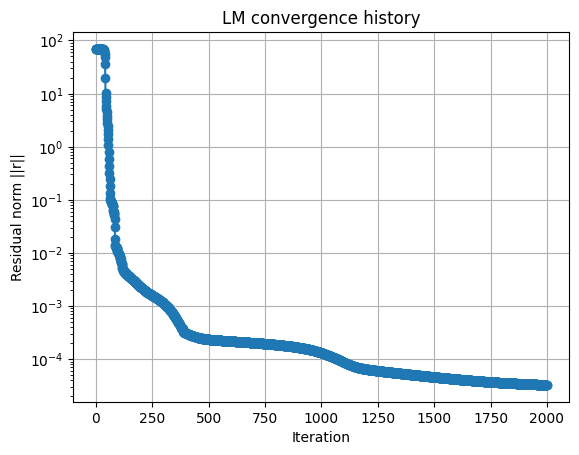

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.semilogy(res_hist, '-o')
plt.xlabel("Iteration")
plt.ylabel("Residual norm ||r||")
plt.title("LM convergence history")
plt.grid(True)
plt.show()


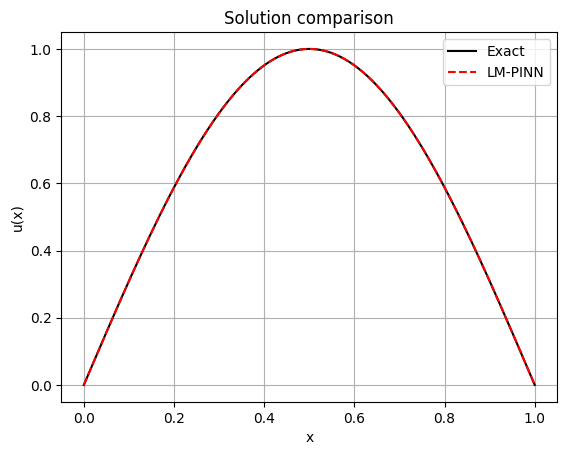

In [33]:
x_plot = torch.linspace(0, 1, 200).view(-1, 1)
with torch.no_grad():
    u_pred = model(x_plot)

u_exact = torch.sin(torch.pi * x_plot)

plt.figure()
plt.plot(x_plot, u_exact, 'k-', label="Exact")
plt.plot(x_plot, u_pred, 'r--', label="LM-PINN")
plt.legend()
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Solution comparison")
plt.grid(True)
plt.show()


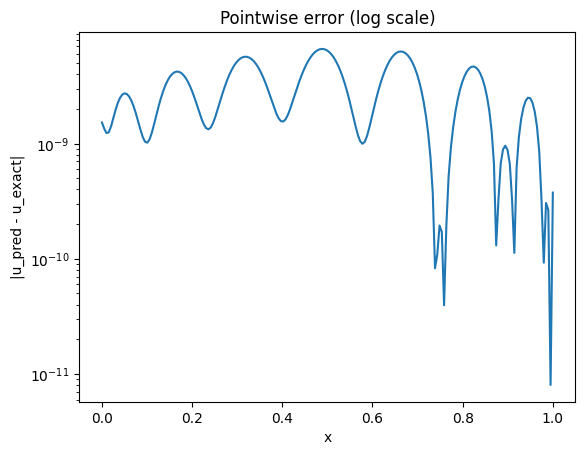

In [34]:
error = torch.abs(u_pred - u_exact)
plt.figure()
plt.semilogy(x_plot, error)
plt.xlabel("x")
plt.ylabel("|u_pred - u_exact|")
plt.title("Pointwise error (log scale)")
#plt.grid(True, which="both") #刻度線
plt.show()


In [35]:
n_theta = sum(p.numel() for p in model.parameters())
print(n_theta)

1021
